In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import plotly.graph_objects as go

import os
# from pyfmreaderpsnex.ps_nex.loadMaps import checkMapFileNULL, remove_nan_and_get_indices, load_map_file_csv, compute_time_difference
# from pyfmreaderpsnex.ps_nex.parseTDMS import get_channel_names, parse_tdms, grab_tdms
# from pyfmreaderpsnex.plotting import smooth_derivative
# import plotly.io as pio
# import seaborn as sns
# import sys

from pyfmreader import loadfile
from pyfmreader.ps_nex.parseTDMS import grab_tdms
from pyfmrheo.utils.force_curves import correct_tilt
from scipy.stats import linregress

pi = math.pi
 

In [2]:
from scipy.signal import savgol_filter

# scan from left to right, corrected deflection, and check when value becomes positive
def find_first_positive(arr):
    """
    Returns an array of first positives in a NumPy array.
    Returns None if no positive value is found.
    """
    arr = np.asarray(arr)
    positives = np.where(arr > 0)[0]
    return positives if positives.size > 0 else None

def savitzky_golay_smooth(y, window_length=11, polyorder=3):
    """
    Applies Savitzky-Golay smoothing to a 1D array.

    Parameters:
    - y: array-like, the signal to smooth
    - window_length: int, length of the filter window (must be odd and >= polyorder+2)
    - polyorder: int, order of the polynomial used to fit the samples

    Returns:
    - smoothed_y: numpy array, the smoothed signal
    # """
    y = np.asarray(y)
    # Ensure window_length is odd and less than or equal to the size of y
    if window_length % 2 == 0:
        window_length += 1
    if window_length > len(y):
        window_length = len(y) if len(y) % 2 == 1 else len(y) - 1
    return savgol_filter(y, window_length=window_length, polyorder=polyorder)



## Read file and parse necessary data

In [3]:
# file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/03/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.31.15.19.tdms'
directory = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/600/'

show_plots = False
correct_zero_lastValue = True

first_file, all_files = grab_tdms(directory)

print(f'number of tdms files found: {len(all_files)}')

number of tdms files found: 100


In [4]:
# Load File
filename = all_files[29] #or 31, 29
# filename = '/Users/evillz/Data/article/2025_07_01_THP1_phd/error_files_test/1000_3/error_file/fcurve_thp1_cell1_ret_1000ums__2025.07.01_17.02.53.84.tdms'
filename = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/10/fcurve_thp1_cell1_ret_100ums__2025.07.01_16.39.13.66.tdms' # <--- felix said good
# filename = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/300/fcurve_thp1_cell1_ret_300ums__2025.07.01_16.49.47.34.tdms'
# filename = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_18.05.48.47.tdms'
# filename = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.50.46.00.tdms'
# filenmae = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.46.48.23.tdms'
# filename = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.48.59.79.tdms'
##6000 um/s
filename = '/Users/evillz/Data/article/20205_07_22_Thp1_AC10/canti1/cell1/6000/fcurve_THP1_AC10_FastVelocities__2025.07.22_16.16.14.20.tdms'

file = loadfile(filename)
filemetadata = file.filemetadata
print(filemetadata['file_type'])
print(f'analyzing file: {filename}')

PSNEX.tdms
analyzing file: /Users/evillz/Data/article/20205_07_22_Thp1_AC10/canti1/cell1/6000/fcurve_THP1_AC10_FastVelocities__2025.07.22_16.16.14.20.tdms


In [5]:
# Filemetadata
file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
K = filemetadata['spring_const_Nbym'] #N/m
height_channel_key = filemetadata['height_channel_key']
deflection_channel_key = filemetadata['deflection_chanel_key']

defl_sens = file_deflection_sensitivity / 1e9 #m/V

print(f"Height channel: {height_channel_key}")
print(f"Deflection Sens.: {defl_sens} m/V")
print(f"spring_const_Nbym: {K} N/m")

Height channel: Zpiezo_stage_sensor_(V)
Deflection Sens.: 2.67e-08 m/V
spring_const_Nbym: 0.1 N/m


In [6]:
# Select curve by index
curve_idx = 0
try : 
    force_curve = file.getcurve(curve_idx, bool_correct_overshoot=True)
except IndexError:
    print(f"Curve index {curve_idx} does not exist in the file.")
    force_curve = None  

# Preprocess curve to get the segments
try:
    force_curve.preprocess_force_curve(defl_sens, height_channel_key)
except Exception as e:
    print(f"Error occurred during preprocessing: {e}")


Correcting overshoot in the approach segment


In [7]:
# Get segments and indentation
segs = force_curve.get_segments()
# these metadata is only available after getting segments
final_nb_points = filemetadata['final_nb_points']
relative_SR = filemetadata['relative_sr']


# get details of retract segments
for segid, segment in segs:
    print (f'segment ID: {segid}, type: {segment.segment_type}, #points: {len(segment.zheight)}, velocity: {segment.velocity} nm/s')
    if segment.segment_type in ('Retract', 'Ret'):
        print(f"Segment ID: {segid}, Type: {segment.segment_type}")
        relative_SR_ret = relative_SR[segid-1]
        vel_ret_um_s = segment.velocity * 1e6  # Convert nm/s to um/s
        print (f'retract_velocity: {vel_ret_um_s} um/s  ')

# print ('relative_SR:', relative_SR_ret)
# print ('relative_freq(hz):', 1 / relative_SR_ret)
# print (f'vel_ret_um_s: {vel_ret_um_s} um/s')
# indentation = ext_data.indentation

segment ID: 0, type: App, #points: 136445, velocity: 1.9997823e-05 nm/s
segment ID: 2, type: Ret, #points: 142758, velocity: 0.006000000000000001 nm/s
Segment ID: 2, Type: Ret
retract_velocity: 6000.000000000001 um/s  


In [8]:
# Get zheight and vdeflection, for now only get retract
zmin_app = 0
for segid, segment in segs:
    if segment.segment_type in ('Approach', 'App'):
        zmin_app = segment.zheight.min()
        app_piezo = -segment.zheight
        app_deflection = -segment.vdeflection * K  # Convert to N
        relative_SR_app = relative_SR[segid-1]
        vel_app_um_s = segment.velocity * 1e6  # Convert nm/s to um/s
        if show_plots:
            plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'g-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.zheight
        ret_deflection = -segment.vdeflection * K  # Convert to N
        ret_velocity = segment.velocity   # Convert nm/s to um/s
        relative_SR_ret = relative_SR[segid-1]
        vel_ret_um_s = segment.velocity * 1e6  # Convert nm/s to um/s
        print (f"Retract velocity: {ret_velocity} m/s" )
        time_ret = np.arange(len(ret_piezo)) * relative_SR_ret  # Assuming relative_SR_ret is in Hz, convert to seconds
        print (f"{len(ret_piezo)}, {len(ret_deflection)}, {len(time_ret )}")
        if show_plots:
            plt.plot(segment.zheight - zmin_app, segment.vdeflection, 'r-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Contact', 'Con', 'Pause'):
        con_piezo = -segment.zheight
        con_deflection = -segment.vdeflection * K  # Convert to N
        con_velocity = segment.velocity   # Convert nm/s to um/s
        relative_SR_con = relative_SR[segid-1]
        if show_plots:
            plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'b-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
if show_plots:
    plt.legend()
    plt.xlabel('displacement (m)')
    plt.ylabel('vdeflection (nm)')

# depening if there is a value , get length of total force curve: app+ con + ret
if 'con_piezo' in locals():
    total_length = len(app_piezo) - len(con_piezo) + len(ret_piezo)
    print(f"Total length of the force curve without contact: {total_length}")


deflection_N = np.concatenate((app_deflection, ret_deflection))
zheight = np.concatenate((app_piezo, ret_piezo)) 

print (len(zheight), len(deflection_N))

# plt.plot(ret_piezo, ret_deflection, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.show()

Retract velocity: 0.006000000000000001 m/s
142758, 142758, 142758
279203 279203


In [9]:
# get the initial deflecton and add to current to offset to zero
if correct_zero_lastValue:
    initial_deflection = deflection_N[:]
    print (f"Initial deflection to correct: {initial_deflection} N")


Initial deflection to correct: [-2.31187162e-10 -2.50697629e-10 -2.24854488e-10 ... -2.27593045e-10
 -2.39915278e-10 -2.43851874e-10] N


deflection_init: 2.31187162399292e-10
Retract velocity: 0.006000000000000001 m/s
142758, 142758, 142758
279203 279203


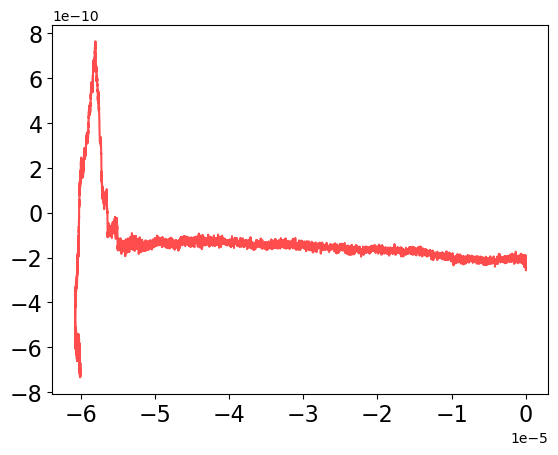

In [10]:
# Get zheight and vdeflection, for now only get retract
zmin_app = 0
for segid, segment in segs:


    if segment.segment_type in ('Approach', 'App'):

        # get initial deflection value to offset
        deflection_init = abs(segment.vdeflection[0]) * K  # in N    
        print (f'deflection_init: {deflection_init}')
        zmin_app = segment.zheight.min()
        app_piezo = -segment.zheight
        app_deflection = -segment.vdeflection * K  # Convert to N
        app_deflection_zero = ((segment.vdeflection * K) + deflection_init )* 1e12
        app_zheight_zero = (segment.zheight - zmin_app)*1e6
        time_app = np.arange(len(app_piezo)) * relative_SR[0]  # Assuming relative_SR is in Hz, convert to seconds

        if show_plots:
            plt.plot(app_zheight_zero, app_deflection_zero, 'g-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.zheight
        ret_deflection = -segment.vdeflection * K  # Convert to N
        ret_velocity = segment.velocity   # Convert nm/s to um/s
        ret_deflection_zero = ((segment.vdeflection * K) + deflection_init )* 1e12
        ret_zheight_zero = (segment.zheight - zmin_app)*1e6
        print (f"Retract velocity: {ret_velocity} m/s" )
        time_ret = (np.arange(len(ret_piezo)) * relative_SR_ret) + time_app[-1] # Assuming relative_SR_ret is in Hz, convert to seconds
        ret_segment_time = segment.time
        print (f"{len(ret_piezo)}, {len(ret_deflection)}, {len(time_ret )}")
        if show_plots:
            plt.plot(ret_zheight_zero, ret_deflection_zero, 'r-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    # elif segment.segment_type in ('Contact', 'Con', 'Pause'):
    #     con_piezo = -segment.zheight
    #     con_deflection = -segment.vdeflection * K  # Convert to N
    #     if show_plots:
    #         plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'b-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
if show_plots:
    plt.legend()
    plt.xlabel('displacement (µm)', fontsize=16)
    plt.ylabel('Force (pN)', fontsize=16)

# depening if there is a value , get length of total force curve: app+ con + ret
if 'con_piezo' in locals():
    total_length = len(app_piezo) - len(con_piezo) + len(ret_piezo)
    print(f"Total length of the force curve without contact: {total_length}")


# set x max min
deflection_N = np.concatenate((app_deflection, ret_deflection))
zheight = np.concatenate((app_piezo, ret_piezo)) 

print (len(zheight), len(deflection_N))

plt.plot(ret_piezo, ret_deflection, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
# set XY tick size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


# To save with transparency, use savefig instead:
plt.savefig('/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/PyFMGUI_DyNaMo/notebook/velocities/force_curve.svg', transparent=True)

plt.show()

### Calculate retract Velocity
retract velocity calculated from linnear regression fit, the slope would be the calcualted average velocity

In [11]:
from scipy.stats import linregress

def calculate_velocity(displacement_um, rel_time):
    """
    Calculate the average velocity from displacement_um and time arrays using linear regression.

    Parameters:
        displacement_um (np.ndarray): Displacement values (in micrometers).
        rel_time (np.ndarray): Time values (in seconds).

    Returns:
        float: Average velocity (slope) in µm/s.
    """
    displacement_um = -displacement_um * 1e6  # Convert to micrometers (for compatibility with previous code)
    # deriv_displacement = np.gradient(displacement_um, rel_time)
    slope, intercept, _, _, _= linregress(rel_time, displacement_um)
    return slope


calculated_velocity = calculate_velocity(-ret_piezo, time_ret)  
print(f'{len(ret_piezo)}, {len(time_ret), time_ret[2]-time_ret[1]}')
print (f"Calculated average velocity: {calculated_velocity:.2f} um/s" )
print(f'metadata_ret_velocity: {vel_ret_um_s:.2f} um/s')

# calculate percent difference from the calculated velocity and the metadata velocity

percent_difference = ((calculated_velocity - vel_ret_um_s) / vel_ret_um_s) *100
print(f"% Error: {percent_difference :.2f}%") 

142758, (142758, np.float64(2.000000000279556e-06))
Calculated average velocity: 21.62 um/s
metadata_ret_velocity: 6000.00 um/s
% Error: -99.64%


### Max min Tilt correction
- taken from pyfmrheo

In [12]:
max_offset = 50  # %
min_offset = 30  # %


In [13]:
def update_tilt_range(zheight, max, min, offset_type='percentage'):
    if offset_type == 'percentage':
        deltaz = zheight.max() - zheight.min()
        maxperc = max / 1e2
        minperc = min / 1e2
        maxoffset = zheight.min() + deltaz * maxperc
        minoffset = zheight.min() + deltaz * minperc
    elif offset_type == 'absolute':
        maxoffset = max / 1e9
        minoffset = min / 1e9
    return maxoffset, minoffset


max_offset, min_offset = update_tilt_range(ret_piezo, max_offset, min_offset, offset_type='percentage')
tilt_ret_deflection_N = correct_tilt(ret_piezo, ret_deflection, max_offset, min_offset)


# if show_plots:
#     plt.plot(ret_piezo, tilt_ret_deflection_N, 'k--', color='blue', linewidth=1.5, label='Tilt Corrected Force curve')
#     plt.legend()

### Find contact point of retract
- take the index at which the negative deflection turns positive

In [14]:
# contact_point_offset_um = 1e-6  # um
# print (len(ret_piezo))
# contact_point_offset_index = int(contact_point_offset_um/ ((ret_piezo[-1] - ret_piezo[0])/len(ret_piezo)))
# print (f"contact_point_offset_index: {contact_point_offset_index}")


index_first_positive = find_first_positive(tilt_ret_deflection_N)[0]
print (f"Index of first positive value in corrected deflection: {index_first_positive}")

first_positive_deflection = tilt_ret_deflection_N[index_first_positive]
first_positive_displacement = ret_piezo[index_first_positive]
print(f"First positive deflection: {first_positive_deflection}, at displacement: {first_positive_displacement}")

Index of first positive value in corrected deflection: 137009
First positive deflection: 4.463287536940766e-14, at displacement: -6.0332789897918705e-05


In [15]:
ret_corrected_displacement = ret_piezo - first_positive_displacement

# time corrected 

time_ret_corrected =  time_ret[index_first_positive] - time_ret

# print(time_ret_corrected)

# plt.plot(time_ret_corrected)

print(f"length of time and ret: {len(time_ret_corrected)}, {len(ret_corrected_displacement)}")

length of time and ret: 142758, 142758


In [16]:
# Find the maximum positive value in corrected_deflection_ret
positive_values = tilt_ret_deflection_N[tilt_ret_deflection_N > 0]
if positive_values.size > 0:
    max_positive_value = np.max(positive_values)
    print(f"Max positive value in corrected_deflection_ret: {max_positive_value}")
else:
    print("No positive values found in corrected_deflection_ret.")

Max positive value in corrected_deflection_ret: 8.681905709832381e-10


first_positive_displacement: -6.0332789897918705e-05 m


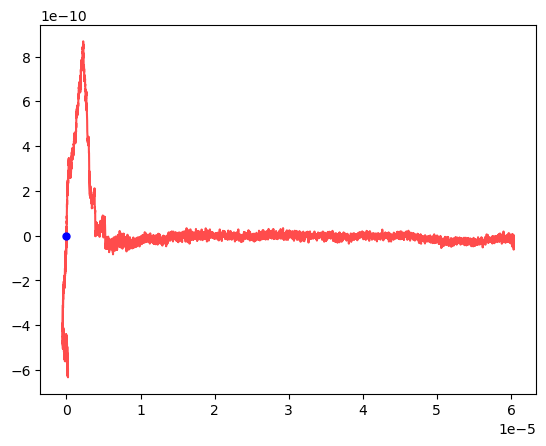

In [17]:

plt.plot(ret_corrected_displacement, tilt_ret_deflection_N, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.plot(0, first_positive_deflection, 'o', color='blue', markersize=5, label='Ret_point of contact')  #

print (f'first_positive_displacement: {first_positive_displacement} m')

# Correct first positive to be equal to last value

In [18]:
# get last value of deflection 
last_deflection_value = tilt_ret_deflection_N[-1]
print (f"last_deflection_value: {last_deflection_value}")
print (type(last_deflection_value   ))


positives = np.where(tilt_ret_deflection_N < last_deflection_value)[0]
# print (positives)

# plt.plot(positives, tilt_ret_deflection_N[positives], 'o', color='green', markersize=5, label='points > last deflection')  #
new_first_positive_deflection = tilt_ret_deflection_N[positives[-1]]
# print (f'deflection at first positive index: {new_first_positive_deflection} N')

tilt_ret_deflection_N = tilt_ret_deflection_N.copy() - new_first_positive_deflection

last_deflection_value: -4.928924501532922e-11
<class 'numpy.float64'>


### Do savtisky or derivative on deflection

In [19]:
sav_win_length = 40
sav_poly_order = 10

In [20]:
# window length needs to be higher than polyorder!
savitz_defl = savitzky_golay_smooth(tilt_ret_deflection_N, window_length=sav_win_length,polyorder=sav_poly_order) 

Index at 7.5 µm: 137477
/Users/evillz/Data/article/20205_07_22_Thp1_AC10/canti1/cell1/6000/fcurve_THP1_AC10_FastVelocities__2025.07.22_16.16.14.20.tdms
figure path: /Users/evillz/Data/article/figures/fcurve_THP1_AC10_FastVelocities__2025.07.22_16.16.14.20_Tether.svg 


/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_4390/709065368.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(ret_corrected_displacement*1e6, savitz_defl*1e9, 'b-',color = 'black',


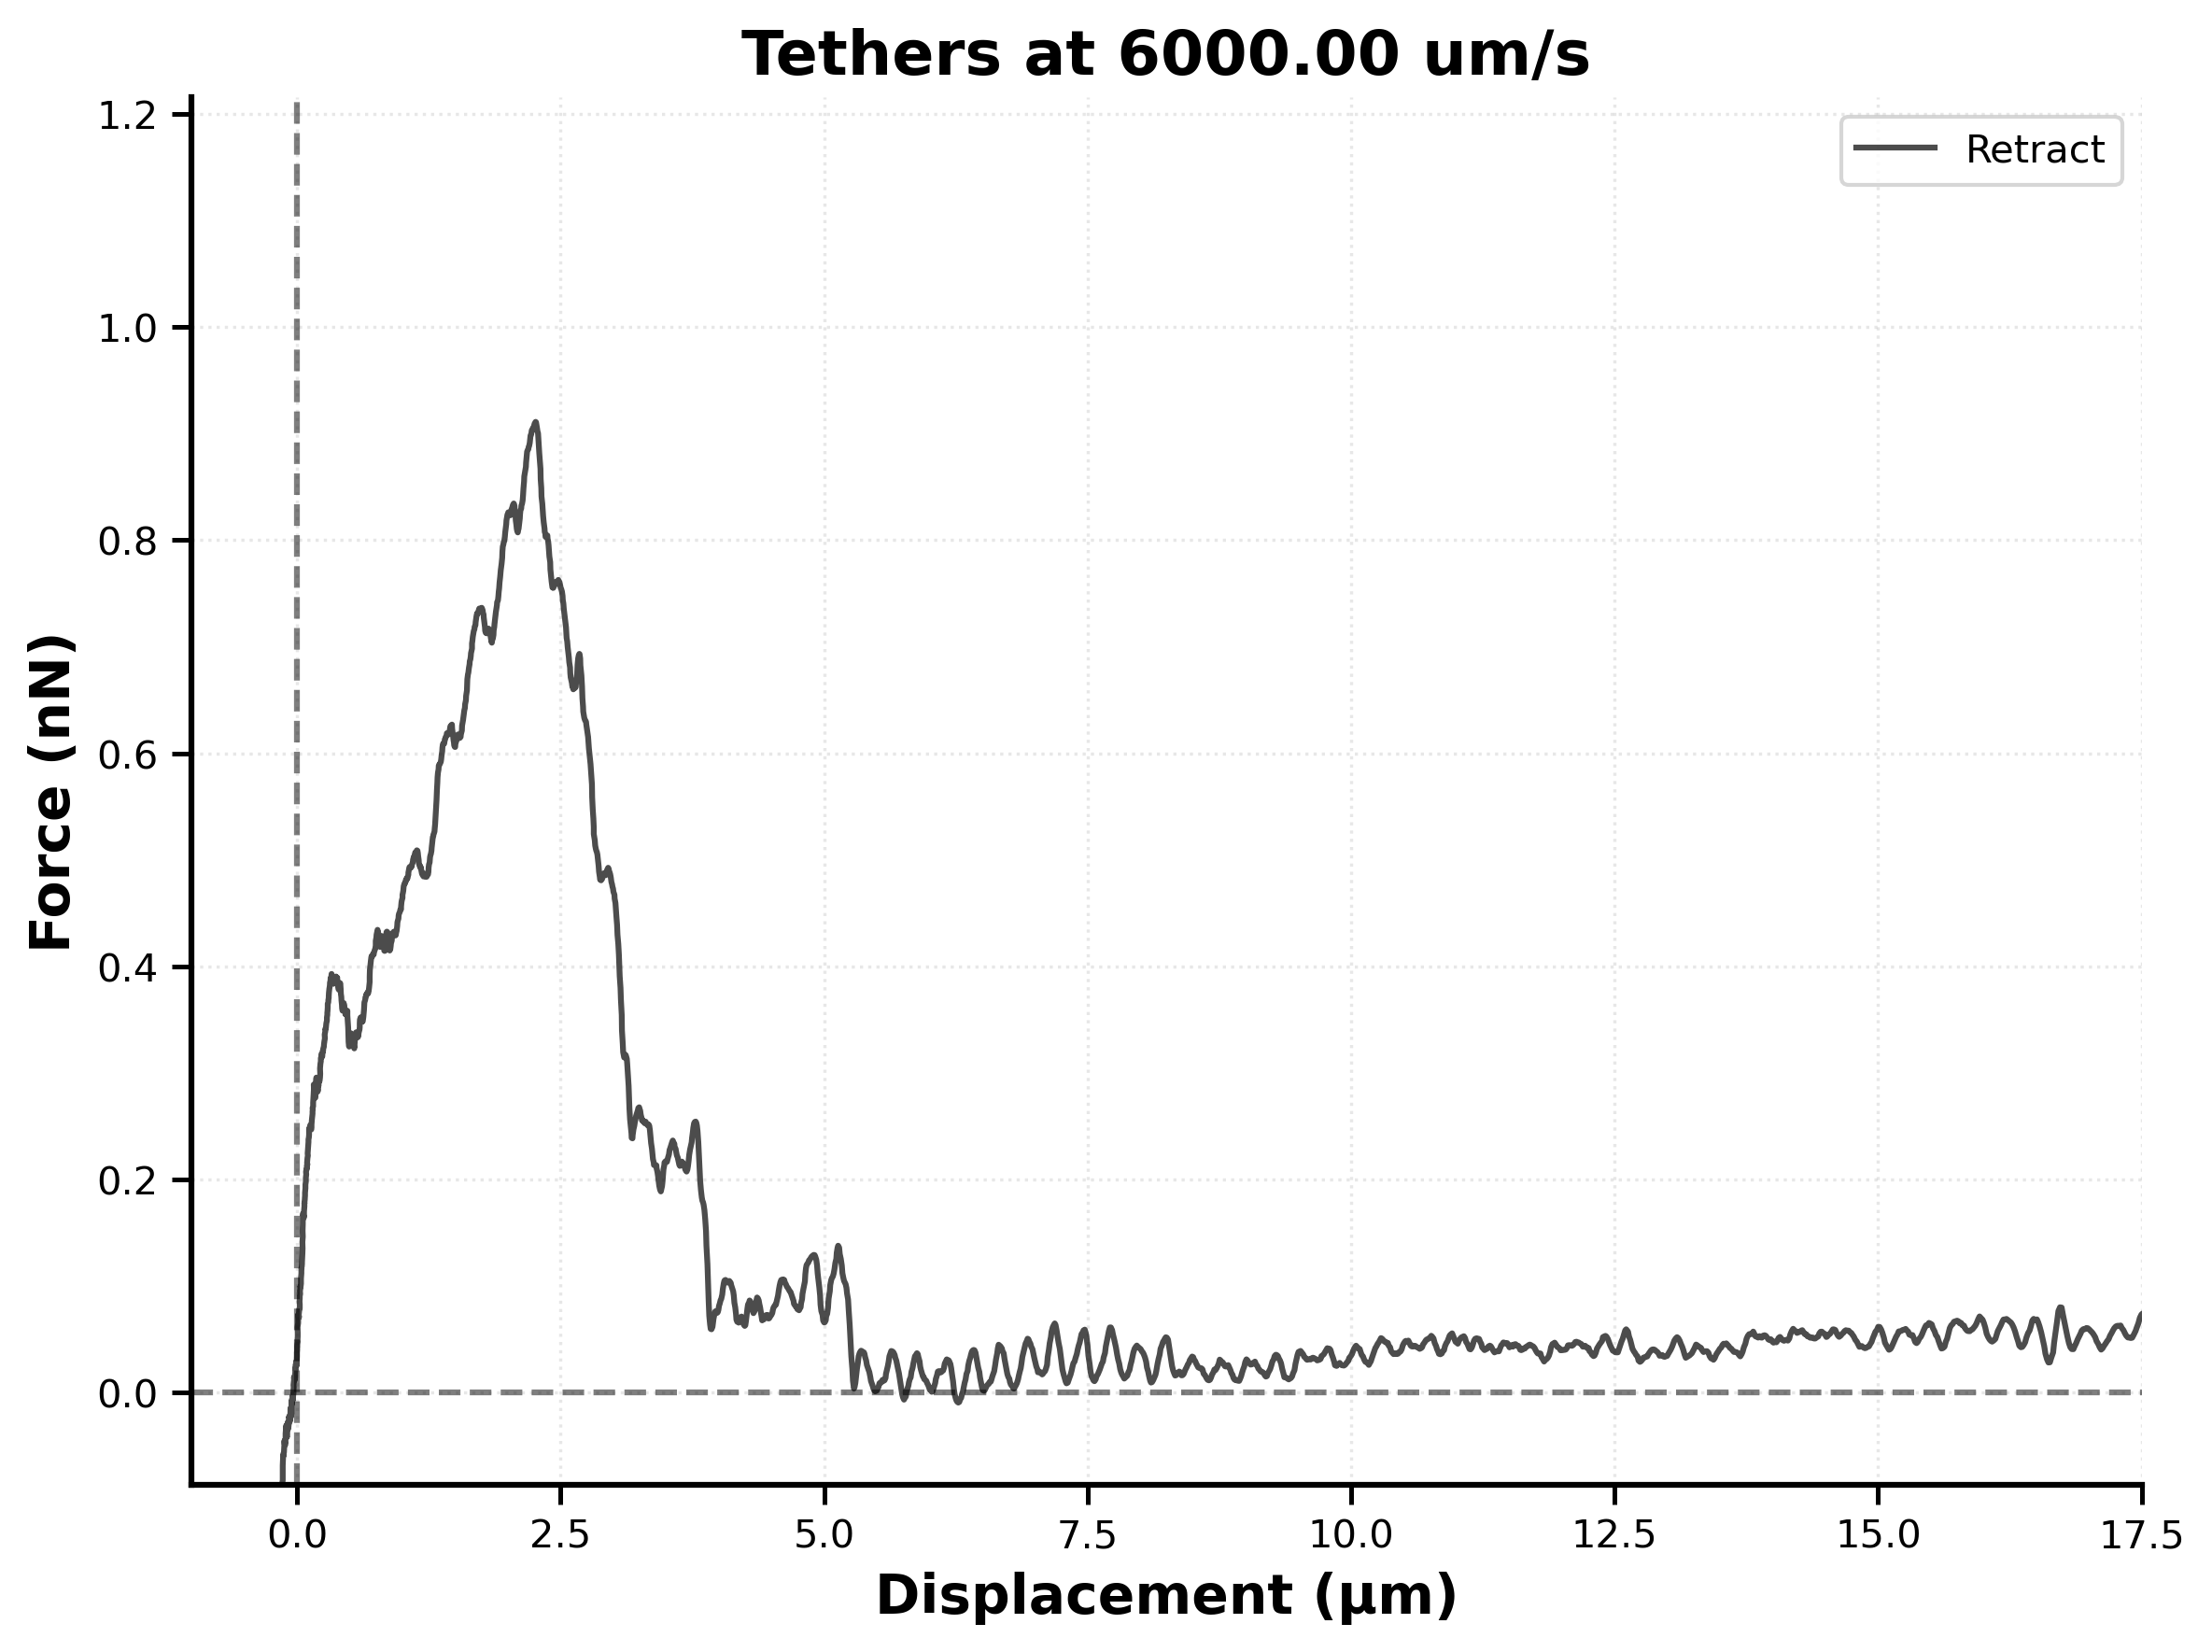

In [21]:
# Create a figure with appropriate size for publication
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Plot the main data with improved styling
# ax.plot(ret_corrected_displacement*1e6, tilt_ret_deflection_N*1e9, 'r-', 
#          linewidth=1.5, label='Retract curve', alpha=0.9)

# get index at 7.5 um
index = np.where(ret_corrected_displacement >= 1e-6)[0][0]
print(f"Index at 7.5 µm: {index}")

ret_corrected_displacement = ret_corrected_displacement[:]
savitz_defl = savitz_defl[:]
ax.plot(ret_corrected_displacement*1e6, savitz_defl*1e9, 'b-',color = 'black',
         linewidth=1.5, label='Retract', alpha=0.7)

# # Mark the contact point more clearly
# ax.plot(0, first_positive_deflection*1e9, 'o', color='blue', 
#          markersize=8, label='Contact point')

# Format the axes with scientific notation and set appropriate limits
y_lower_limit = tilt_ret_deflection_N.min()*0.15*1e9
y_upper_limit = max_positive_value*1.4*1e9
ax.set_ylim(y_lower_limit, y_upper_limit)
ax.set_xlim(-1, 17.5)
# Add reference lines
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)

# Improve axis labels with units
ax.set_ylabel('Force (nN)', fontsize=14, fontweight='bold')
ax.set_xlabel('Displacement (µm)', fontsize=14, fontweight='bold')
ax.set_title(f'Tethers at {vel_ret_um_s:.2f} um/s', fontsize=16, fontweight='bold')

# Add grid for better readability
ax.grid(True, linestyle=':', alpha=0.3)

# Format tick labels
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
ax.tick_params(labelsize=10)

# Remove the top and right spines (the box boundaries)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optionally, thicken x and y axes for emphasis
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Make ticks point outward for a clean look
ax.tick_params(direction='out', length=5, width=1.2)


# Optimize legend
ax.legend(loc='best', frameon=True, fontsize=10)

# Tight layout to optimize space
plt.tight_layout()

# save as svg file
save_plots = True
dir_path = '/Users/evillz/Data/article/figures'
print(filename)
fig_path = os.path.join(dir_path, os.path.basename(filename)[:-5]+'_Tether.svg')
print(f'figure path: {fig_path} ')
if save_plots:
    plt.savefig(fig_path, format='svg', dpi=300, transparent=True)
    plt.show()

In [23]:
# Calculate aspect ratio from data ranges
x_range = ret_corrected_displacement.max() - ret_corrected_displacement.min()
y_range = savitz_defl.max() - savitz_defl.min()

aspect_ratio = x_range / y_range

print(f"X range: {x_range*1e6:.2f} µm")
print(f"Y range: {y_range*1e9:.2f} nN")
print(f"Aspect ratio (X/Y): {aspect_ratio:.2e}")

X range: 60.86 µm
Y range: 1.47 nN
Aspect ratio (X/Y): 4.13e+04


In [22]:
# calculate aspect ratio from data ranges   


